# Pipeline related stuff

-e .
mne, mne_icalabel
ipykernel
onnxruntime
pyprep, meegkit

In [1]:
import mne
import os
from speed.pipeline_challenge import BasePipeline, PretrainPipeline
from pathlib import Path
import numpy as np
import h5py

## Preprocessing pipeline

In [2]:
# raw_path  = "/data/agjma/HBN_EEG_Raw/ds005505/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set" 
raw_path = "/dtu-compute/EEG_at_scale/tuh_eeg/data/tuh_eeg/v2.0.0/edf/066/aaaaajwo/s002_2010_06_03/01_tcp_ar/aaaaajwo_s002_t000.edf"
raw = mne.io.read_raw_edf(raw_path, preload=True)

Extracting EDF parameters from /dtu-compute/EEG_at_scale/tuh_eeg/data/tuh_eeg/v2.0.0/edf/066/aaaaajwo/s002_2010_06_03/01_tcp_ar/aaaaajwo_s002_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143749  =      0.000 ...   574.996 secs...


In [3]:
raw

<RawEDF | aaaaajwo_s002_t000.edf, 36 x 143750 (575.0 s), ~39.5 MiB, data loaded>

In [4]:
# raw = mne.io.read_raw_eeglab(raw_path, preload=True)
# print(raw.ch_names)
hbn_channels = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E67', 'E68', 'E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'Cz']
tuh_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

In [5]:
pipeline = PretrainPipeline(
    do_ica=False, 
    line_freqs=60, 
    channels_rename=None, 
    montage_name="tuh", 
    channels=tuh_channels, 
    window_length=30, 
    shift_seconds=0,
    hp_freq=0.5,
    lp_freq=50,
    return_quality_metrics=False,
    drop_bad_quality=True,
    fit_to_hbn_montage=False,
)

raws, times, indices = pipeline([raw_path], )

2025-10-17 11:08:54,998 - root - INFO - File: aaaaajwo_s002_t000.	Dropped 13 channels when setting montage: ['Roc', 'Loc', 'Ekg1', 'Emg', '26', '27', '28', '29', '30', 'Photic', 'Ibi', 'Bursts', 'Suppr'].


KeyboardInterrupt: 

In [ ]:
pipeline = PretrainPipeline(
    do_ica=False, 
    line_freqs=60, 
    channels_rename=None, 
    montage_name="tuh", 
    channels=tuh_channels, 
    window_length=30, 
    shift_seconds=0,
    hp_freq=0.5,
    lp_freq=50,
    return_quality_metrics=False,
    drop_bad_quality=True,
    fit_to_hbn_montage=True,
)

raws, times, indices = pipeline([raw_path], )

## Check manually if file looks okay: 


In [22]:
data1_path = "/scratch/linsk/tuh_test_preprocessed/data_1.hdf5"
with h5py.File(data1_path, 'r') as f:
    # print(dict(f.attrs).keys())
    data = f['data'][:]
    print(data.shape) # (windows, 105, 3000)
    print(f.attrs["files"])

(40, 19, 3000)
['aaaaabaz_s001_t000']


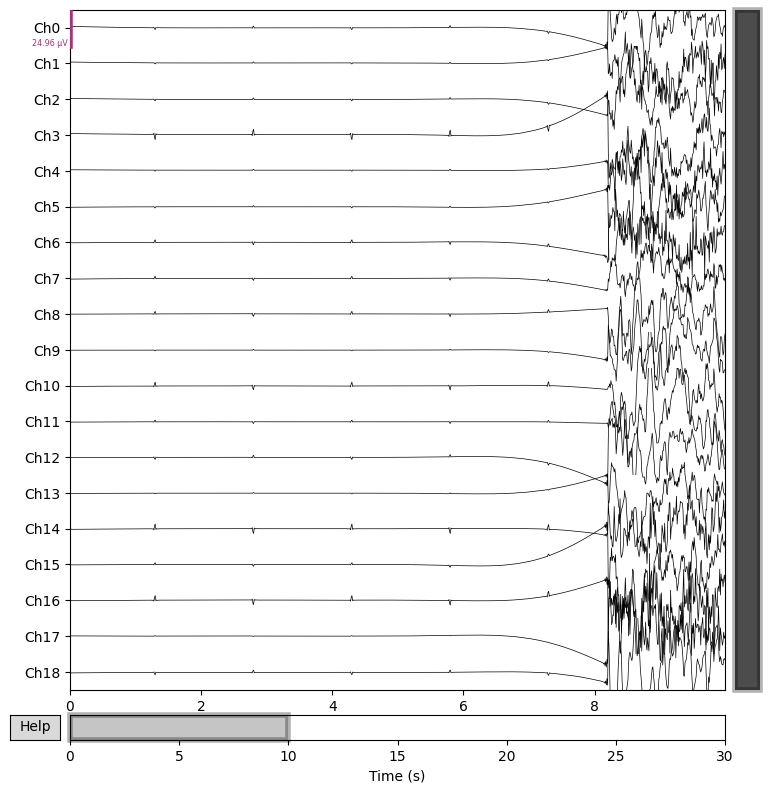

''

In [19]:
import mne

window_idx = 0
eeg_data = data[window_idx] 

sfreq = 100 
ch_names = [f"Ch{i}" for i in range(eeg_data.shape[0])]
ch_types = ["eeg"] * eeg_data.shape[0]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(eeg_data, info)

raw.plot(scalings='auto', title=f"Window {window_idx}", show=True)
;


In [ ]:
# WHY NOT DROPPED??

In [20]:
import pandas as pd 
log_file = "/scratch/linsk/tuh_test_preprocessed/logs/quality_metrics.csv"
df = pd.read_csv(log_file, sep=",", header=0)

In [24]:
# get above file name: 
df['filename'][0]

'/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_28/02_tcp_le/aaaaabaz_s001_t000.edf'

In [21]:
df

,filename,window_start_time,window_end_time,oha1,thv1,chv1,bcr1,oha2,thv2,chv2,bcr2
0,/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_...,0.0,30.0,0.041189,0.081333,0.041667,0.208333,NaN,NaN,NaN,NaN
1,/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_...,30.0,60.0,0.117950,0.084133,0.000000,0.083333,NaN,NaN,NaN,NaN
2,/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_...,60.0,90.0,0.163400,0.052667,0.000000,0.208333,NaN,NaN,NaN,NaN
3,/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_...,90.0,120.0,0.090917,0.001067,0.000000,0.166667,NaN,NaN,NaN,NaN
4,/scratch/linsk/tuh_test/aaaaabaz/s001_2003_11_...,120.0,150.0,0.098289,0.018400,0.000000,0.083333,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
118,/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_...,1170.0,1200.0,0.157289,0.085333,0.041667,0.125000,NaN,NaN,NaN,NaN
119,/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_...,1200.0,1230.0,0.044994,0.099067,0.041667,0.208333,NaN,NaN,NaN,NaN
120,/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_...,1230.0,1260.0,0.043217,0.041200,0.041667,0.125000,NaN,NaN,NaN,NaN
121,/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_...,1260.0,1290.0,0.116656,0.069067,0.041667,0.166667,NaN,NaN,NaN,NaN


- <span style="color:red">(oha < 0.8)</span> Overall High Amplitude - frac samples across channels that exceed a high amplitude threshold (oha_threshold). Large values - spikes or artifacts.
- <span style="color:red">(thv < 0.5)</span> Temporal High Variance - frac time points where standard deviation across channels exceeds thv_threshold.
- <span style="color:red">(chv < 0.5)</span> Channel High Variance - frac chans where standard deviation exceeds chv_threshold.
- <span style="color:red">(bcr < 0.8)</span> Bad Channel Ratio

## Align montages: 


In [2]:
from mne.channels import make_dig_montage
from speed.utils import  make_tuh_montage
from speed.methods import PreprocessMethods

In [3]:
raw_path_hbn  = "/scratch/linsk/hbn_test/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set"
raw_path_tuh = "/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf"

raw_hbn = mne.io.read_raw_eeglab(raw_path_hbn, preload=True)
raw_tuh = mne.io.read_raw_edf(raw_path_tuh, preload=True)

Extracting EDF parameters from /scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 330249  =      0.000 ...  1320.996 secs...


In [4]:
def get_channel_positions(raw):
    """Return a dict {ch_name: xyz} for channels that have locations."""
    positions = {}
    for ch in raw.info['chs']:
        ch_name = ch['ch_name']
        loc = ch['loc'][:3]  # first 3 elements are x, y, z
        if np.any(loc):  # skip if all zeros
            positions[ch_name] = loc
    return positions

In [5]:
positions_hbn = {ch: pos for ch, pos in get_channel_positions(raw_hbn).items()}
montage_hbn = make_dig_montage(ch_pos=positions_hbn, coord_frame='head')
montage_gsn = mne.channels.make_standard_montage('GSN-HydroCel-128')
montage_10_20 = mne.channels.make_standard_montage('standard_1020')

montage_tuh = make_tuh_montage()
PreprocessMethods.to_standard_names(raw_tuh)
PreprocessMethods.set_montage(raw_tuh, montage_tuh);

### Get HBN montage:

In [28]:
tuh_to_hbn_dict = {'Fp1': 'E25',
 'Fp2': 'E8',
 'F3': 'E24',
 'F4': 'E124',
 'C3': 'E36',
 'C4': 'E104',
 'P3': 'E60',
 'P4': 'E85',
 'O1': 'E70',
 'O2': 'E83',
 'F7': 'E33',
 'F8': 'E122',
 'T7': 'E45',
 'T8': 'E108',
 'T5': 'E58',
 'T6': 'E96',
 'Fz': 'E5',
 'Cz': 'Cz',
 'Pz': 'E62'}


In [38]:
# hbn_montage script: 
raw_path_hbn  = "/scratch/linsk/hbn_test/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_eeg.set"
raw_hbn = mne.io.read_raw_eeglab(raw_path_hbn, preload=True)
positions_hbn = {ch['ch_name']: ch['loc'][:3] for ch in raw_hbn.info['chs'] if np.any(ch['loc'][:3])}

positions_hbn_filtered = {ch: loc for ch, loc in positions_hbn.items() if ch in tuh_to_hbn_dict.values()}

montage_hbn = make_dig_montage(ch_pos=positions_hbn, coord_frame='head')
montage_hbn.save('montage-hbn128-dig.fif', overwrite= True)

montage_hbn2 = mne.channels.read_dig_fif('montage-hbn-dig.fif')
# raw_hbn.set_montage(montage_hbn2)

# raw_path_tuh = "/scratch/linsk/tuh_test/aaaaabay/s001_2003_05_20/02_tcp_le/aaaaabay_s001_t000.edf"
# raw_tuh = mne.io.read_raw_edf(raw_path_tuh, preload=True)
# montage_tuh = make_tuh_montage()
# PreprocessMethods.to_standard_names(raw_tuh)
# PreprocessMethods.set_montage(raw_tuh, montage_tuh)


# raw = raw_tuh.interpolate_to(sensors=montage_hbn2, method='spline')

In [35]:
montage_hbn2

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 19 channels>

### Montage plots

In [ ]:
# combined_montage.plot();

    # fig = combined_montage.plot(kind='3d', show_names=True)
    # fig.suptitle("Combined Montage (20 + 20 channels)", fontsize=14)

ten20 = mne.channels.make_standard_montage('standard_1020')
ten20.plot();

gsn = mne.channels.make_standard_montage('GSN-HydroCel-128')

In [ ]:
import matplotlib.pyplot as plt

def plot_two_montages_2d(montage1, montage2, color1='blue', color2='red'):
    pos1 = montage1.get_positions()['ch_pos']
    pos2 = montage2.get_positions()['ch_pos']

    fig, ax = plt.subplots(figsize=(6, 6))

    # Montage 
    # Montage 1
    for ch, pos in pos1.items():
        ax.scatter(pos[0], pos[1], color=color1, label='Montage 1' if ch == list(pos1.keys())[0] else "", alpha=0.7)
        ax.text(pos[0], pos[1], ch, fontsize=8, color=color1, ha='center')

    # Montage 2
    for ch, pos in pos2.items():
        ax.scatter(pos[0], pos[1], color=color2, label='Montage 2' if ch == list(pos2.keys())[0] else "", alpha=0.7)
        ax.text(pos[0], pos[1], ch, fontsize=8, color=color2, ha='center')

    ax.legend()
    ax.set_title("Overlay of Two Montages (2D projection)")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.axis('equal')
    plt.show()



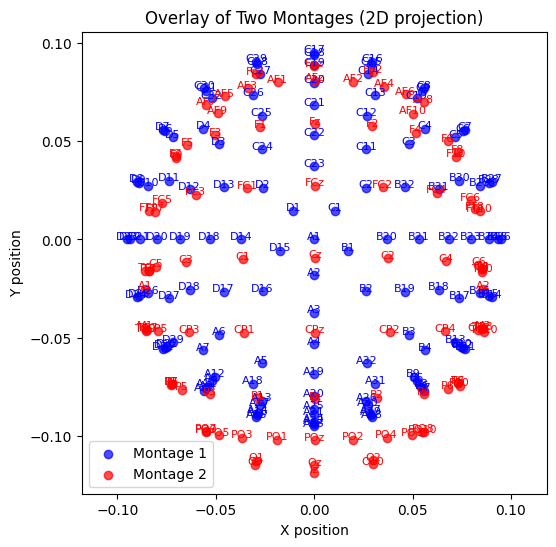

In [36]:
montage1 = mne.channels.make_standard_montage("biosemi128")
montage2 = mne.channels.make_standard_montage("standard_1020")

plot_two_montages_2d(montage1, montage2, color1='blue', color2='red')


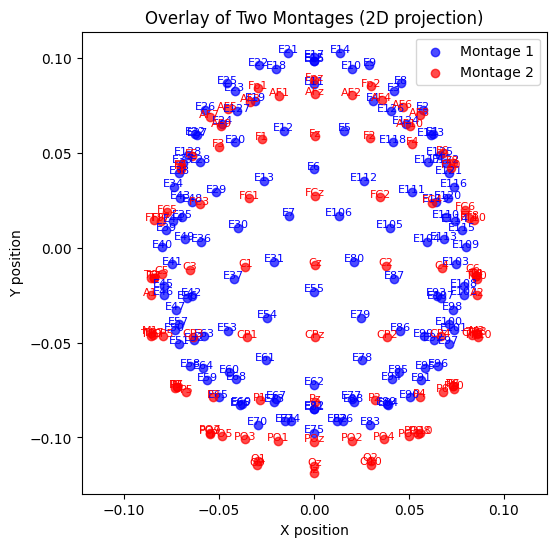

In [37]:
montage1 = mne.channels.make_standard_montage("GSN-HydroCel-128")
montage2 = mne.channels.make_standard_montage("standard_1020")

plot_two_montages_2d(montage1, montage2, color1='blue', color2='red')

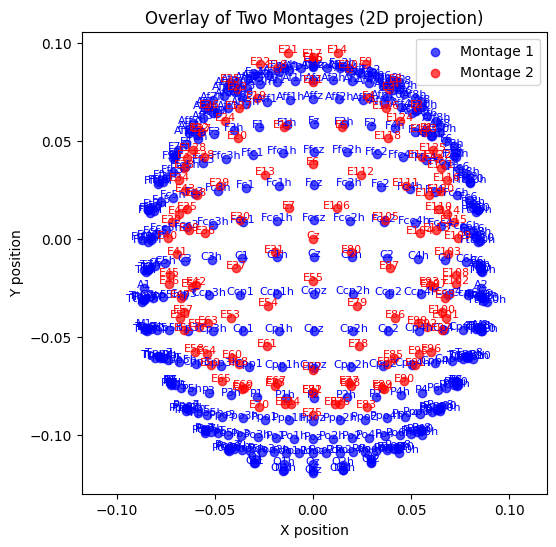

In [55]:
plot_two_montages_2d(montage_tuh, montage_hbn, color1='blue', color2='red')

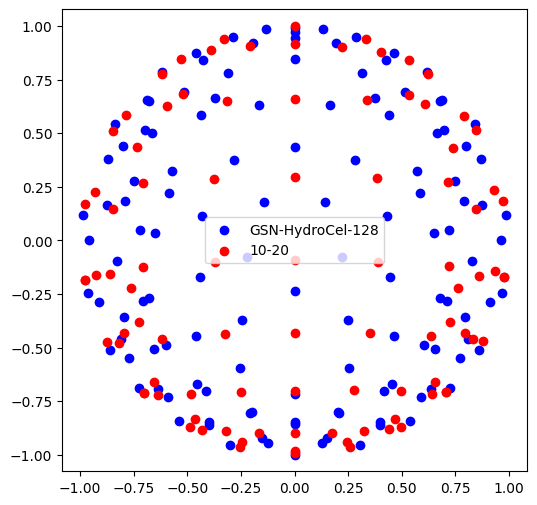

In [38]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_two_montages_2d_unit(montage1, montage2, color1='blue', color2='red'):
    # get positions
    pos1 = np.array(list(montage1.get_positions()['ch_pos'].values()))
    pos2 = np.array(list(montage2.get_positions()['ch_pos'].values()))
    
    # normalize to unit vectors (remove scale)
    pos1_uv = pos1 / np.linalg.norm(pos1, axis=1)[:, None]
    pos2_uv = pos2 / np.linalg.norm(pos2, axis=1)[:, None]
    
    # project to 2D (simple orthographic)
    def proj(xyz):
        return xyz[:, 0], xyz[:, 1]
    
    x1, y1 = proj(pos1_uv)
    x2, y2 = proj(pos2_uv)
    
    plt.figure(figsize=(6,6))
    plt.scatter(x1, y1, c=color1, label='GSN-HydroCel-128')
    plt.scatter(x2, y2, c=color2, label='10-20')
    plt.axis('equal')
    plt.legend()
    plt.show()

# Example usage
montage1 = mne.channels.make_standard_montage("GSN-HydroCel-128")
montage2 = mne.channels.make_standard_montage("standard_1020")
plot_two_montages_2d_unit(montage1, montage2)


### mapping: rotation + translation from hbn to tuh 

Clean up below

In [ ]:
from mne.coreg import fit_matched_points
from mne.transforms import apply_trans
from mne.transforms import Transform

from mne.transforms import read_trans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import cKDTree


In [ ]:
fids_tuh = raw_tuh.info['dig'][:3]
fids_hbn = raw_hbn.info['dig'][:3]

fids_hbn_arr = np.array([f['r'] for f in fids_hbn], dtype=float)
fids_tuh_arr = np.array([f['r'] for f in fids_tuh], dtype=float)

# add cz to both:
fids_tuh_arr = np.vstack([fids_tuh_arr, get_channel_positions(raw_tuh)['Cz']])
fids_hbn_arr = np.vstack([fids_hbn_arr, get_channel_positions(raw_hbn)['Cz']])

In [ ]:
trans = fit_matched_points(fids_hbn_arr, fids_tuh_arr, 'similarity')  # map montage2 → montage1

In [ ]:
# load raw_tuh, then:
# montage_tuh = make_tuh_montage()
# PreprocessMethods.to_standard_names(raw_tuh)
# PreprocessMethods.set_montage(raw_tuh, montage_tuh);

tuh_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
positions_tuh = get_channel_positions(raw_tuh) # 24?
positions_tuh = {k:v for k, v in positions_tuh.items() if k in tuh_channels} # should only be 19 now 
# all_positions_tuh = montage_tuh.get_positions()['ch_pos'] # full 345?
montage_tuh_subset = make_dig_montage(ch_pos=positions_tuh, coord_frame='head')

#### below code to create .fif file that can be loaded into mne coreg gui for manual alignment

In [ ]:
# for d, name in zip(montage_tuh_subset.dig, tuh_channels):
#     d['ch_name'] = name

# montage_tuh_subset._coord_frame = 'head'
# montage_tuh_subset.save('montage-tuh-dig.fif', overwrite = True)
# # [d.get('ch_name') for d in montage_tuh_subset.dig] # check if names exist

In [23]:
# # Create dummy Raw with only channel names
# ch_names = [d['ch_name'] for d in montage_tuh_subset.dig]
# info = mne.create_info(ch_names=ch_names, sfreq=1000., ch_types='eeg')

# # Set montage
# raw_dummy = mne.io.RawArray(np.zeros((len(ch_names), 1)), info)
# raw_dummy.set_montage(montage_tuh_subset)

# # Save
# raw_dummy.save('tuh_raw_dummy.fif')

Creating RawArray with float64 data, n_channels=19, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.
Writing /home/linsk/code/SPEED/notebooks/tuh_raw_dummy.fif
Closing /home/linsk/code/SPEED/notebooks/tuh_raw_dummy.fif
[done]


/tmp/ipykernel_1392295/1787117970.py:10: RuntimeWarning: This filename (/home/linsk/code/SPEED/notebooks/tuh_raw_dummy.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_dummy.save('tuh_raw_dummy.fif')


[PosixPath('/home/linsk/code/SPEED/notebooks/tuh_raw_dummy.fif')]

#### plot if above alignments worked

In [9]:
trans = read_trans('tuh_to_hbn2-trans.fif')

In [13]:
# Extract electrode positions
montage_pos = np.array([d['r'] for d in montage_tuh_subset.dig])

# Apply rigid head->head transform manually
aligned_pos = apply_trans(trans, montage_pos)

# Update the montage
for d, r_new in zip(montage_tuh_subset.dig, aligned_pos):
    d['r'] = r_new


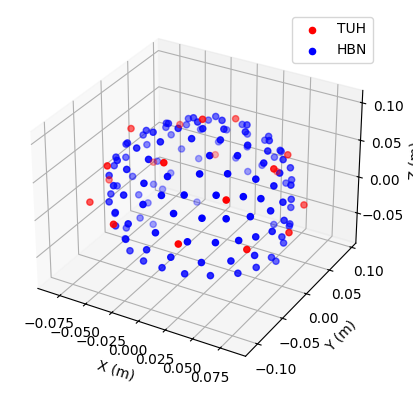

In [14]:
# Example: TUH (aligned) and HBN template
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# TUH montage (after alignment)
tuh_pos = np.array([d['r'] for d in montage_tuh_subset.dig])
ax.scatter(tuh_pos[:,0], tuh_pos[:,1], tuh_pos[:,2], c='r', label='TUH')

# HBN template
hbn_pos = np.array([d['r'] for d in montage_hbn.dig])
ax.scatter(hbn_pos[:,0], hbn_pos[:,1], hbn_pos[:,2], c='b', label='HBN')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()


In [15]:
R = trans[:3, :3]
scale = np.cbrt(np.linalg.det(R))  # approximate uniform scale
print("Scale factor applied:", scale)



TypeError: unhashable type: 'slice'

In [12]:
# If your transform is called 'trans'
matrix = trans['trans']  # this is the 4x4 numpy array

# Extract rotation+scale
R = matrix[:3, :3]

# Approximate uniform scale
scale = np.cbrt(np.linalg.det(R))
print("Scale factor applied:", scale)


Scale factor applied: 1.0000000124001283


### get closest electrodes after alignment

In [16]:
# TUH electrode positions after rigid alignment
tuh_pos = np.array([d['r'] for d in montage_tuh_subset.dig])


In [17]:
tuh_pos

array([[-0.0292763 ,  0.08713075, -0.00700956],
       [ 0.03003189,  0.08809643, -0.00737086],
       [-0.04988495,  0.05790634,  0.04321021],
       [ 0.05218867,  0.05903876,  0.0413815 ],
       [-0.06491158, -0.00609717,  0.06748299],
       [ 0.0675602 , -0.00541265,  0.06614552],
       [-0.05259741, -0.07348885,  0.06115287],
       [ 0.05607822, -0.07325951,  0.0613261 ],
       [-0.02919586, -0.10863334,  0.01504989],
       [ 0.03005951, -0.10835148,  0.01476157],
       [-0.0701216 ,  0.04557484, -0.00995525],
       [ 0.07318094,  0.04747925, -0.01117732],
       [-0.08401338, -0.01282045, -0.00596766],
       [ 0.08522569, -0.01185498, -0.00682886],
       [-0.07226092, -0.07000948,  0.00266503],
       [ 0.07322768, -0.06965089,  0.0020105 ],
       [ 0.00076922,  0.06406716,  0.06709139],
       [ 0.00099245, -0.00250443,  0.1030059 ],
       [ 0.0008422 , -0.07497618,  0.08767208]])

In [18]:
# HBN electrode positions (template)
hbn_pos = np.array([d['r'] for d in montage_hbn.dig])
hbn_ch_names = list(montage_hbn.get_positions()['ch_pos'].keys())

In [20]:
# Build KD-tree on HBN template
tree = cKDTree(hbn_pos)

# Find closest HBN electrode for each TUH electrode
dist, idx = tree.query(tuh_pos)
closest_hbn_chs = [hbn_ch_names[i] for i in idx] # list
tuh_to_hbn = {tuh: hbn_ch_names[i] for tuh, i in zip(positions_tuh.keys(), idx)} # dict


In [21]:
tuh_to_hbn

{'Fp1': 'E25',
 'Fp2': 'E8',
 'F3': 'E24',
 'F4': 'E124',
 'C3': 'E36',
 'C4': 'E104',
 'P3': 'E60',
 'P4': 'E85',
 'O1': 'E70',
 'O2': 'E83',
 'F7': 'E33',
 'F8': 'E122',
 'T7': 'E45',
 'T8': 'E108',
 'T5': 'E58',
 'T6': 'E96',
 'Fz': 'E5',
 'Cz': 'Cz',
 'Pz': 'E62'}

In [22]:
## plot to verify ( in 2d)

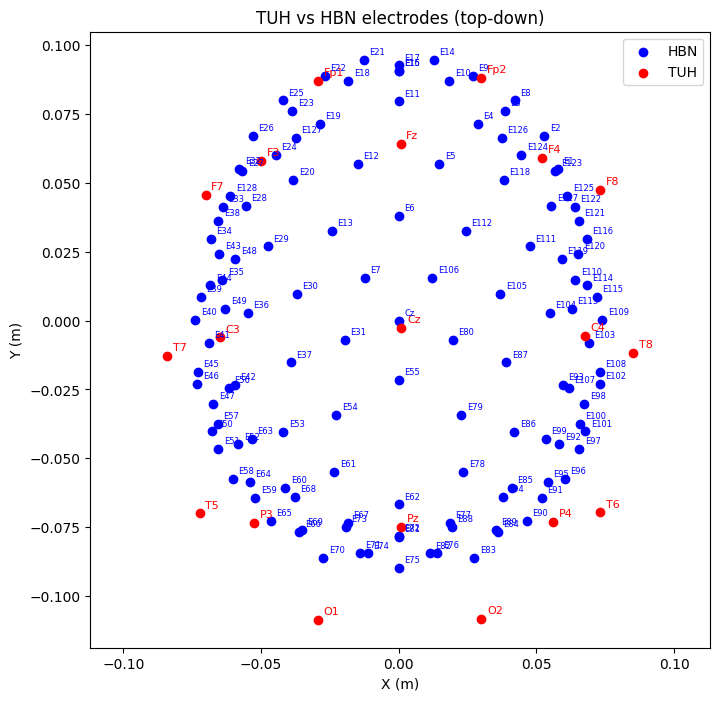

In [23]:
import matplotlib.pyplot as plt

# XY positions
tuh_xy = tuh_pos[:, :2]
hbn_xy = hbn_pos[:, :2]

plt.figure(figsize=(8,8))
plt.scatter(hbn_xy[:,0], hbn_xy[:,1], c='blue', label='HBN')
plt.scatter(tuh_xy[:,0], tuh_xy[:,1], c='red', label='TUH')

# Add TUH labels
for i, name in enumerate(positions_tuh.keys()):
    plt.text(tuh_xy[i,0]+0.002, tuh_xy[i,1]+0.002, name, color='red', fontsize=8)

# Add HBN labels
for i, name in enumerate(hbn_ch_names):
    plt.text(hbn_xy[i,0]+0.002, hbn_xy[i,1]+0.002, name, color='blue', fontsize=6)

plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('TUH vs HBN electrodes (top-down)')
plt.legend()
plt.axis('equal')
plt.show()


In [ ]:
# 